# Level 1 - Task 2: Exploratory Data Analysis (EDA) and Visualization
**Dataset:** House Prediction Dataset  
**Objective:** Explore the dataset, generate descriptive statistics, visualize data distributions, and analyze feature correlations to understand key factors influencing house prices.

In [1]:
# Import Needed Libraries 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the cleaned dataset produced from Task 1
df = pd.read_excel('cleaned_house_data.xlsx')

# Display the first 5 rows to verify the data
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTATE  PRICE  
0  396.90    4.98   24.0  
1  396.90    9.14   21.6  
2  392.83    4.03   34.7  
3  394.63    2.94   33.4  
4  396.90    5.33   36.2  


## 1. Descriptive Statistics
  Extracting statistical summaries (mean, standard deviation, min, max, percentiles) for all numerical features in the dataset.

In [2]:
# Generate and print the Statistical summary of the dataframe
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

## 2. Price Distribution Analysis
  Visualizing the distribution of the target variable (`PRICE`) to understand the spread and identify potential outliers or skewness.

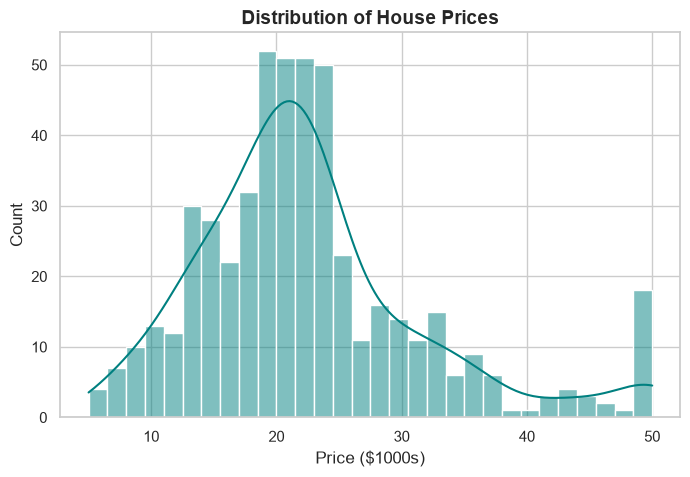

In [3]:
# Set the visual style for seaborn
sns.set_theme(style = 'whitegrid')

# Plot the distribution of house prices with a Kernal Density Estimate (KDE) line
plt.figure(figsize = (8, 5))
sns.histplot(df['PRICE'], kde = True, color = 'teal', bins = 30)
plt.title('Distribution of House Prices', fontsize = 14, fontweight = 'bold')
plt.xlabel('Price ($1000s)', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.show()

## 3. Feature Correlation Analysis
  Generating a Correlation Matrix heatmap to evaluate linear relationships between different features and identify which variables have the strongest impact on house prices (`PRICE`).

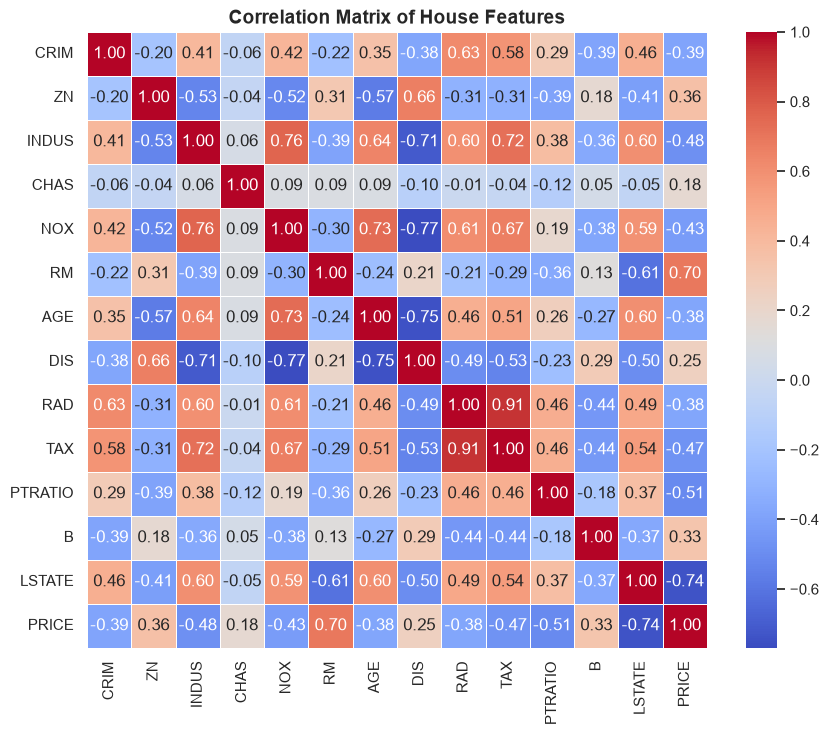

In [4]:
# Calculate the correlation matrix for all features
correlation_matrix = df.corr()

# PLot the correlation heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidth = 0.5,
    cbar = True
)
plt.title(
    'Correlation Matrix of House Features', fontsize = 14, fontweight = 'bold'
)
plt.show()

## 4. Key Feature Relationships (Scatter Plots)
Visualizing the direct relationship between house prices (`PRICE`) and critical predictor variables (`RM` and `LSTAT`) to understand linear trends and patterns.

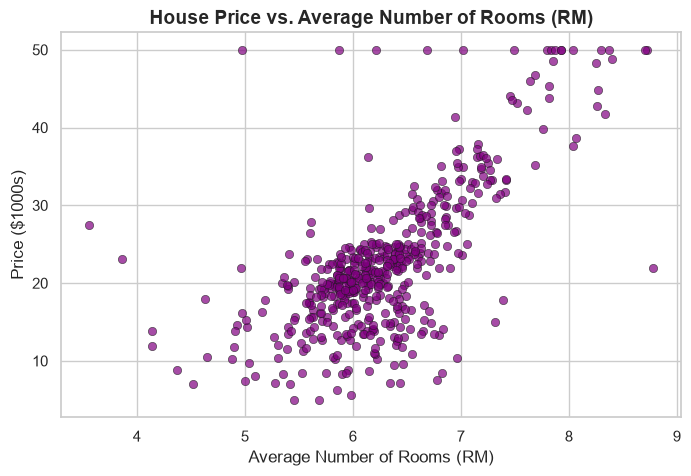

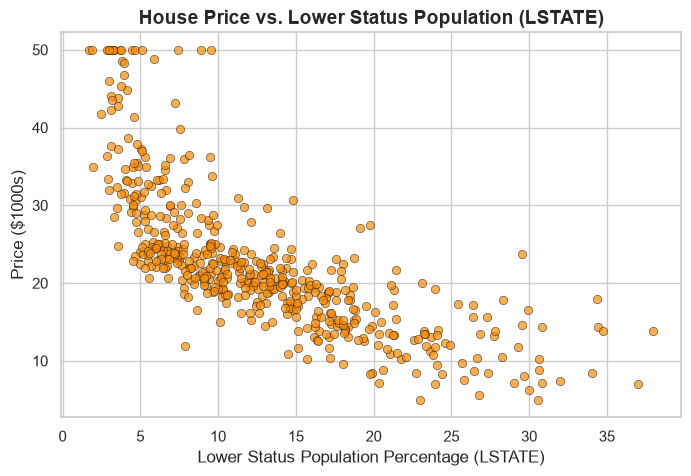

In [5]:
# Set visual style
sns.set_theme(style = 'whitegrid')

# 1. Scatter Plot: RM (Rooms) vs PRICE
plt.figure(figsize = (8, 5))
sns.scatterplot(
    x = 'RM',
    y = 'PRICE',
    data = df,
    color = 'purple',
    alpha = 0.7,
    edgecolor = 'k'
)
plt.title(
    'House Price vs. Average Number of Rooms (RM)',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Average Number of Rooms (RM)', fontsize=12)
plt.ylabel('Price ($1000s)', fontsize=12)
plt.show()

# 2. Scatter Plot: LSTAT (Lower Status) vs PRICE
plt.figure(figsize = (8, 5))
sns.scatterplot(
    x = 'LSTATE',
    y = 'PRICE',
    data = df,
    color = 'darkorange',
    alpha = 0.7,
    edgecolor = 'k',
)
plt.title(
    'House Price vs. Lower Status Population (LSTATE)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Lower Status Population Percentage (LSTATE)', fontsize=12)
plt.ylabel('Price ($1000s)', fontsize=12)
plt.show()

## 📊 Key Insights & Exploratory Data Analysis Takeaways

After performing the exploratory data analysis and visualizing the feature correlations for the house prediction dataset, we can draw the following key conclusions:

1. **Target Correlation (PRICE):**
   - **Positive Correlation:** The average number of rooms (`RM`) exhibits a strong positive correlation with house prices (`PRICE`), meaning that homes with more rooms generally command higher market values.
   - **Negative Correlation:** The percentage of lower-status population (`LSTAT`) shows a strong negative correlation with house prices, indicating that areas with a higher proportion of lower-status residents tend to have lower median home values.

2. **Feature Interdependencies (Multicollinearity Check):**
   - Certain features display moderate to high collinearity (such as nitric oxides concentration `NOX` and proportion of non-retail business acres `INDUS`, or age `AGE` with distance `DIS`). This is a critical observation that will guide feature selection and handling of multicollinearity in the upcoming regression modeling phase (Level 2).

3. **Data Distribution:**
   - The distribution plot of the target variable (`PRICE`) shows a reasonably balanced distribution with slight right-skewness, reflecting standard market conditions where luxury or high-end properties exist as outliers.

*These insights provide a solid statistical foundation for building accurate predictive models in the next stages.*